In [1]:
# Step 1: Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

print("All libraries imported successfully!")


All libraries imported successfully!


In [2]:
# Step 2: Load the Dataset
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data, data.target.rename("HousePrice")], axis=1)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully!
Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
# Step 3: Separate Features and Target Variable
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (20640, 8)
Target shape: (20640,)


In [4]:
# Step 4: Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature scaling done!")
print("All features now have mean ~0 and std ~1")

Feature scaling done!
All features now have mean ~0 and std ~1


In [5]:
# Step 5: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])

Training set size: 16512
Test set size: 4128


In [6]:
# Step 6: Train Multiple Models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=5)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name}: Training complete.")

Linear Regression: Training complete.
Ridge Regression: Training complete.
Decision Tree: Training complete.


In [7]:
# Step 7: Evaluate and Compare All Models
results = {}

for name, model in models.items():
    predictions = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    results[name] = {"RMSE": round(rmse, 4), "R2 Score": round(r2, 4)}

results_df = pd.DataFrame(results).T
print(results_df)

                     RMSE  R2 Score
Linear Regression  0.7456    0.5758
Ridge Regression   0.7456    0.5758
Decision Tree      0.7242    0.5997


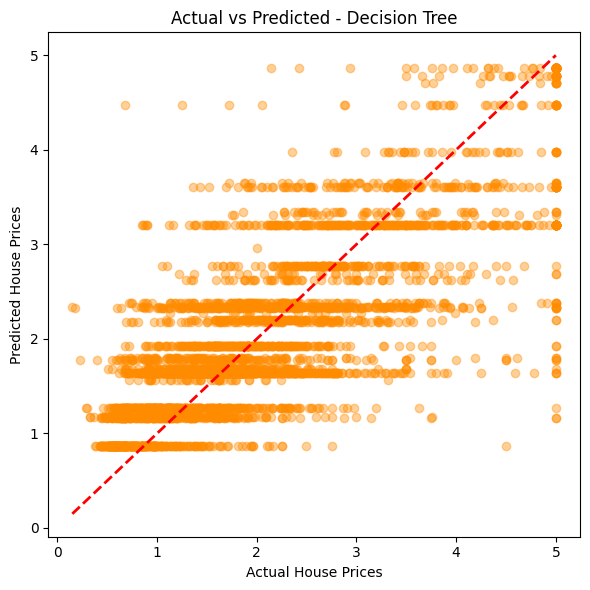

In [8]:
 # Step 8: Actual vs Predicted Plot (Best Model - Decision Tree)
best_model = models["Decision Tree"]
y_pred = best_model.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.4, color="darkorange")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted - Decision Tree")
plt.tight_layout()
plt.show()

In [9]:
# Step 9: Save the Best Model
import joblib

joblib.dump(best_model, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Best model saved as best_model.pkl")
print("Scaler saved as scaler.pkl")

Best model saved as best_model.pkl
Scaler saved as scaler.pkl
